# 02 — Feature characterization audit on the AB extent (Gate AB-0a, part ii)

The parent's Gate-0a protocol (`analyses/y2y/01_feature_audit.ipynb`) re-run **verbatim** on the AB
stack: rules R1–R4 with the frozen constants (`config.AUDIT`: θ=5×, a_min=0.5%, t_min=0.15,
λ=0.10), universal transform screening, F8, feature cards, the D2 archive. Spec §5; methods_log
M2.6–M2.7. Kernel `y2y-geo`. **Zero solves.**

Two conventions, both by design:

- **R1–R4 run at the parent's 30%-of-extent budget** (`config.BUDGET_PCT`) — required for the C2
  comparison to be like-for-like. Leverage at the *effective* AB budget (`spec/ab_extent_v1.json`)
  is reported beside it as a supplementary column.
- **No class is asserted.** Class flips relative to the parent table are results (C2), not errors.

Supplementary zero-solve columns (spec v0.3 §4): `banked_capture`, `residual_target`,
`pre_satisfied`; plus the meaningful-target-window proxy (M2.7). Then the H-AB1/2/3/5 verdict block.

In [6]:
# ---- Setup -------------------------------------------------------------------------------------
import sys, pathlib, importlib, json
import numpy as np
import pandas as pd
import rasterio

_cands = [p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "config.py").exists()]
assert _cands, "config.py not found above the notebook"
ROOT = _cands[0]
sys.path.insert(0, str(ROOT))
import config, leverage_core as lc
importlib.reload(config); importlib.reload(lc)

HERE = ROOT / "analyses" / "alberta_prioritization"
SPEC, FIGS = HERE / "spec", HERE / "figures"
AUDIT_OBJ, CARDS = HERE / "audit" / "audit_objects_ab", HERE / "audit" / "feature_cards_ab"
C2_DIR = HERE / "analysis" / "c2_audit_compare"
for _d in (FIGS, AUDIT_OBJ, CARDS, C2_DIR):
    _d.mkdir(parents=True, exist_ok=True)
AB = config.AB_HANDOFF_DIR
assert (AB / "manifest.json").exists(), "AB stack/manifest missing -- run 01_ab_extent_stack first"
EXTENT = json.loads((SPEC / "ab_extent_v1.json").read_text())
PARENT_T2 = pd.read_csv(ROOT / "analyses/y2y/audit/audit_objects/feature_characterization.csv")

def read(path):
    with rasterio.open(path) as s:
        return s.read(1, masked=True).astype("float64").filled(np.nan)

print("R4 constants (FROZEN, inherited from the parent):")
for k, v in config.AUDIT.items():
    print(f"  {k:<14} {v}")
print(f"  budget_pct     {config.BUDGET_PCT}   (audit convention; effective AB solve budget = {EXTENT['budget_pct_effective']:.4f})")
print(f"AB PU {EXTENT['n_pu']:,} | locked {EXTENT['n_locked']:,} ({100*EXTENT['locked_share']:.1f}%)")

R4 constants (FROZEN, inherited from the parent):
  theta          5.0
  a_min          0.005
  t_min          0.15
  leverage_min   0.1
  rare_cap       0.999
  curve_points   10001
  budget_pct     0.3   (audit convention; effective AB solve budget = 0.4470)
AB PU 85,133 | locked 27,972 (32.9%)


## R1 — universal transform screening on the AB extent

In [7]:
# ---- R1: every feature x {identity, log1p, sqrt} (+ flip/reciprocal where cost-oriented) -------
for name in lc.continuous_features():
    print(f"{name}:")
    for label, d in lc.transform_response(name, handoff_dir=AB).items():
        print(f"    {label:<28} lev={d['leverage']:.3f}  {d['cls']:<28} "
              f"{'ADMISSIBLE' if d['admissible'] else 'screened only'}")
    print()

human_modification:
    identity (avoid direction)   lev=0.729  diffuse-linear               screened only
    1 - x                        lev=0.086  low-contrast-inexpressible   ADMISSIBLE
    log1p                        lev=0.067  low-contrast-inexpressible   screened only
    sqrt                         lev=0.046  low-contrast-inexpressible   screened only

transboundary_connectivity:
    identity                     lev=0.523  diffuse-linear               ADMISSIBLE
    log1p                        lev=0.383  diffuse-linear               screened only
    sqrt                         lev=0.313  diffuse-linear               screened only

climate_corridors:
    identity                     lev=0.100  diffuse-linear               ADMISSIBLE
    log1p                        lev=0.045  low-contrast-inexpressible   screened only
    sqrt                         lev=0.050  low-contrast-inexpressible   screened only

climate_type_macrorefugia:
    identity (avoid direction)   lev=0.286

## T2 — the AB characterization table (R1–R4) + leverage at the effective budget

In [8]:
# ---- T2 on the AB stack (no class asserted) + supplementary leverage at the effective budget -----
tbl, efg_caps = lc.characterization_table(AB)
pu = lc.pu_mask(AB)
eff = EXTENT["budget_pct_effective"]
sup = []
for name in tbl.feature:
    v = read(AB / f"{name}.tif")[pu]
    lo, hi, lev = lc.leverage_of(v, budget_pct=eff)
    sup.append(dict(feature=name, cap_min_eff=round(lo, 3), cap_max_eff=round(hi, 3), leverage_eff=round(lev, 3)))
tbl = tbl.merge(pd.DataFrame(sup), on="feature")
print(f"\nleverage at the parent 30% convention vs at the effective AB budget ({eff:.1%}):")
print(f"{'feature':<32}{'lev@30%':>9}{'lev@eff':>9}{'cap_max@30%':>13}{'cap_max@eff':>13}")
for _, r in tbl.iterrows():
    print(f"{r.feature:<32}{r.leverage:9.3f}{r.leverage_eff:9.3f}{r.cap_max:13.3f}{r.cap_max_eff:13.3f}")

feature                                orient leverage  cap_max theta_area theta_tgt   class -> lever (target)
human_modification                 complement    0.086    0.331     0.0000     0.000   low-contrast-inexpressible -> none (disclosed) (1.0)
transboundary_connectivity                raw    0.523    0.592     0.0034     0.022   diffuse-linear -> weight (1.0)
climate_corridors                         raw    0.100    0.356     0.0000     0.000   diffuse-linear -> weight (1.0)
climate_type_macrorefugia          reciprocal    0.309    0.478     0.0000     0.000   diffuse-linear -> weight (1.0)
irrecoverable_carbon_biomass              raw    0.606    0.636     0.0005     0.003   diffuse-linear -> weight (1.0)
irrecoverable_carbon_m_soc                raw    0.916    0.920     0.0515     0.322   concentrated-satiating -> target (0.322)
aoh_richness_mammals                      raw    0.070    0.333     0.0000     0.000   low-contrast-inexpressible -> none (disclosed) (1.0)
aoh_richn

## Banked capture, residual targets, pre-satisfaction (spec §4, H-AB5) + target window proxy (M2.7)

Everything here is read off the AB stack + the PA mask — zero solves. `banked_capture` = share of
the feature's AB total inside locked cells; `residual_target` = max(0, t − banked); `pre_satisfied`
= banked ≥ implied target. The window proxy = banked + (additions ÷ discretionary cells) ×
(discretionary mass share) — what an area-proportional fill of the additions budget would capture
incidentally; a derived target below it is a decoration (parent E10), flagged here and priced at AB-1.

In [9]:
# ---- Supplementary columns --------------------------------------------------------------------------
with rasterio.open(AB / "mask_protected_areas.tif") as s:
    locked = (s.read(1) == 1) & pu
disc = pu & ~locked
disc_budget_share = EXTENT["additions_cells"] / int(disc.sum())
print(f"locked {int(locked.sum()):,} | discretionary {int(disc.sum()):,} | additions {EXTENT['additions_cells']:,} "
      f"= {100*disc_budget_share:.1f}% of discretionary cells\n")

rows = []
for _, r in tbl.iterrows():
    v = read(AB / f"{r.feature}.tif")
    v = np.where(np.isfinite(v), np.clip(v, 0, None), 0.0)
    tot = v[pu].sum()
    banked, dshare = v[locked].sum() / tot, v[disc].sum() / tot
    t = float(r.target)
    proxy = banked + disc_budget_share * dshare
    rows.append(dict(feature=r.feature, cls=r.cls, target=t, banked_capture=round(banked, 4),
                     residual_target=round(max(0.0, t - banked), 4), pre_satisfied=bool(banked >= t),
                     window_floor_proxy=round(proxy, 4),
                     target_in_window=(bool(t > proxy) if t < 1.0 else None)))
SUP = pd.DataFrame(rows)
print(f"{'feature':<32}{'class':<28}{'target':>7}{'banked':>8}{'residual':>9}{'pre_sat':>8}{'floor':>7}{'in_win':>8}")
for _, r in SUP.iterrows():
    print(f"{r.feature:<32}{r.cls:<28}{r.target:7.3f}{r.banked_capture:8.3f}{r.residual_target:9.3f}"
          f"{str(r.pre_satisfied):>8}{r.window_floor_proxy:7.3f}{('--' if r.target_in_window is None else str(r.target_in_window)):>8}")

# EFG block: banked share of occurrence mass (major=2/minor=1) per EFG; 'pre_satisfied' at t=1 means
# the EFG lies ENTIRELY inside locked cells (nothing left to add).
erows = []
for p in lc.efg_paths(AB):
    e = read(p); e = np.where(np.isfinite(e), e, 0.0)
    tot = e[pu].sum()
    erows.append(dict(feature=p.stem, cap_max=round(efg_caps[p.stem], 3), banked_capture=round(e[locked].sum() / tot, 4)))
EFG_SUP = pd.DataFrame(erows).sort_values("banked_capture", ascending=False)
n_all_in = int((EFG_SUP.banked_capture >= 0.999).sum())
print(f"\nEFG block ({len(EFG_SUP)} present): {n_all_in} entirely inside locked cells (banked >= 0.999); "
      f"median banked {EFG_SUP.banked_capture.median():.3f}; top 8:")
for _, r in EFG_SUP.head(8).iterrows():
    print(f"   {r.feature:<52} banked {r.banked_capture:.3f}  cap_max {r.cap_max:.3f}")
SUP.to_csv(AUDIT_OBJ / "supplementary_columns.csv", index=False)
EFG_SUP.to_csv(AUDIT_OBJ / "efg_supplementary_columns.csv", index=False)
print(f"\nwrote {AUDIT_OBJ.relative_to(ROOT)}/supplementary_columns.csv + efg_supplementary_columns.csv")

locked 27,972 | discretionary 57,161 | additions 10,083 = 17.6% of discretionary cells

feature                         class                        target  banked residual pre_sat  floor  in_win
human_modification              low-contrast-inexpressible    1.000   0.356    0.644   False  0.469      --
transboundary_connectivity      diffuse-linear                1.000   0.385    0.615   False  0.493      --
climate_corridors               diffuse-linear                1.000   0.360    0.640   False  0.473      --
climate_type_macrorefugia       diffuse-linear                1.000   0.456    0.544   False  0.552      --
irrecoverable_carbon_biomass    diffuse-linear                1.000   0.239    0.761   False  0.373      --
irrecoverable_carbon_m_soc      concentrated-satiating        0.322   0.714    0.000    True  0.765   False
aoh_richness_mammals            low-contrast-inexpressible    1.000   0.325    0.675   False  0.444      --
aoh_richness_birds              diffuse-linear  

## F8, feature cards, archive

Cards render at the AB extent (panel E's thumbnail is the AB strip inside the full parent grid).
One disclosure: the summary sheet's red diamonds are the module's **parent** pre-transform
leverages (0.742 gHM, 0.353 macrorefugia); the AB pre-transform values are printed below from the
R1 screening so the reviewer has the right numbers.

wrote /Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/analyses/alberta_prioritization/figures/F8_ab_marginal_density_trajectories.png
wrote 10 pages -> /Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/analyses/alberta_prioritization/audit/feature_cards_ab  (8 feature cards + EFG block card + summary sheet; the spec's '12 cards' counts inputs as '8 continuous + EFG block' = 9 pages -- miscount disclosed)
archived -> /Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/analyses/alberta_prioritization/audit/audit_objects_ab/feature_audit.npz + feature_characterization.csv + audit_constants.json  (8 layers hashed)
  AB pre-transform (raw/avoid) leverage: human_modification           0.729  (parent diamond: 0.742)
  AB pre-transform (raw/avoid) leverage: climate_type_macrorefugia    0.286  (parent diamond: 0.353)


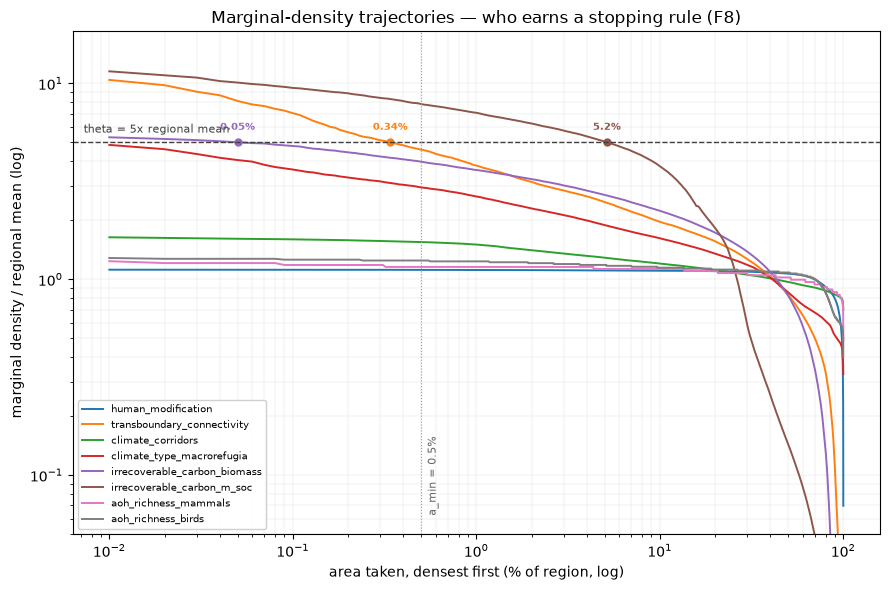

In [10]:
# ---- F8 + cards + archive (all on the AB stack) ----------------------------------------------------
fig = lc.trajectory_figure(FIGS / "F8_ab_marginal_density_trajectories.png", handoff_dir=AB)
card_paths = lc.feature_cards(CARDS, handoff_dir=AB)
lc.audit_archive(AUDIT_OBJ, tbl, handoff_dir=AB)
for name in ("human_modification", "climate_type_macrorefugia"):
    tr = lc.transform_response(name, handoff_dir=AB)
    raw = tr["identity (avoid direction)"]["leverage"]
    print(f"  AB pre-transform (raw/avoid) leverage: {name:<28} {raw:.3f}  (parent diamond: "
          f"{ {'human_modification': 0.742, 'climate_type_macrorefugia': 0.353}[name] })")

## C2 — AB vs parent characterization, and the H-AB1/2/3/5 verdicts

Directional hypotheses were registered in spec §5 **before** this ran. The block below scores them
mechanically; the narrative goes to `gate_ab0a_reportback.md` and the numbers to `results_log.md` R1.

In [11]:
# ---- C2 side-by-side + flip list -------------------------------------------------------------------
c2 = PARENT_T2[["feature", "leverage", "cap_max", "theta_target", "cls", "target"]].rename(
        columns=lambda c: c if c == "feature" else f"{c}_y2y").merge(
     tbl[["feature", "leverage", "cap_max", "theta_target", "cls", "target", "leverage_eff"]].rename(
        columns=lambda c: c if c in ("feature", "leverage_eff") else f"{c}_ab"), on="feature")
c2["flip"] = c2.cls_y2y != c2.cls_ab
print(f"{'feature':<32}{'lev y2y':>8}{'lev AB':>8}{'lev@eff':>8}{'tgt y2y':>8}{'tgt AB':>8}  class y2y -> AB")
for _, r in c2.iterrows():
    print(f"{r.feature:<32}{r.leverage_y2y:8.3f}{r.leverage_ab:8.3f}{r.leverage_eff:8.3f}{r.target_y2y:8.3f}{r.target_ab:8.3f}  "
          f"{r.cls_y2y.replace('low-contrast-','')} -> {r.cls_ab.replace('low-contrast-','')}{'   FLIP' if r.flip else ''}")
c2.to_csv(C2_DIR / "c2_characterization_compare.csv", index=False)

par_efg_rare, par_efg_n = 36, 40
n_efg = len(efg_caps)
n_rare = sum(1 for c in efg_caps.values() if c >= config.AUDIT["rare_cap"])
print(f"\nEFG block: parent {par_efg_n} present / {par_efg_rare} rare-attainable  ->  AB {n_efg} present / {n_rare} rare-attainable "
      f"/ {n_efg - n_rare} unsaturated")

# ---- Hypothesis verdicts (spec s5) ------------------------------------------------------------------
row = c2.set_index("feature"); sup = SUP.set_index("feature")
ghm = row.loc["human_modification"]
low4 = ["human_modification", "climate_type_macrorefugia", "transboundary_connectivity", "aoh_richness_birds", "aoh_richness_mammals"]
V = {}
V["H-AB1"] = dict(
    ghm_leverage_y2y=float(ghm.leverage_y2y), ghm_leverage_ab=float(ghm.leverage_ab),
    ghm_crosses_lambda=bool(ghm.leverage_ab >= config.AUDIT["leverage_min"]),
    s5_expressible=bool(ghm.cls_ab != "low-contrast-inexpressible"),
    contrast_delta={f: round(float(row.loc[f].leverage_ab - row.loc[f].leverage_y2y), 3) for f in low4},
    verdict=("SUPPORTED: gHM crosses lambda -> S5 expressible at AB extent (D3(b) scale footnote)" if ghm.leverage_ab >= config.AUDIT["leverage_min"]
             else f"NOT SUPPORTED on the strongest expectation: gHM {ghm.leverage_ab:.3f} < lambda {config.AUDIT['leverage_min']}; see per-feature deltas"))
V["H-AB2"] = dict(efg_present=n_efg, efg_rare=n_rare, efg_unsaturated=n_efg - n_rare, parent=dict(present=40, rare=36),
                  verdict=f"{'SUPPORTED' if n_efg < 40 else 'NOT SUPPORTED'}: {n_efg}/40 EFGs survive; unsaturated {n_efg - n_rare} vs parent 4")
ms = row.loc["irrecoverable_carbon_m_soc"]
V["H-AB3"] = dict(msoc_cls_ab=ms.cls_ab, msoc_target_ab=float(ms.target_ab), msoc_theta_target_ab=float(ms.theta_target_ab),
                  parent_target=0.332, verdict=f"m_soc {ms.cls_ab} (target {ms.target_ab:.3f} vs parent 0.332) -- no direction was registered; this IS the finding")
pre = SUP[SUP.pre_satisfied].feature.tolist()
resid = SUP.sort_values("residual_target", ascending=False)
V["H-AB5"] = dict(pre_satisfied=pre, banked=SUP.set_index("feature").banked_capture.round(3).to_dict(),
                  top_residual=resid.head(3)[["feature", "residual_target"]].values.tolist(),
                  verdict=(f"{len(pre)} feature(s) pre-satisfied at lock: {pre}" if pre else "NO continuous feature is pre-satisfied at lock")
                          + f"; highest residual pull: {resid.iloc[0].feature} ({resid.iloc[0].residual_target:.3f})")
print()
for h, d in V.items():
    print(f"{h}: {d['verdict']}")
(SPEC / "gate_ab0a_verdicts.json").write_text(json.dumps(V, indent=1, default=str))
print(f"\nwrote spec/gate_ab0a_verdicts.json + {C2_DIR.relative_to(ROOT)}/c2_characterization_compare.csv")

feature                          lev y2y  lev AB lev@eff tgt y2y  tgt AB  class y2y -> AB
human_modification                 0.042   0.086   0.094   1.000   1.000  inexpressible -> inexpressible
transboundary_connectivity         0.461   0.523   0.594   1.000   1.000  diffuse-linear -> diffuse-linear
climate_corridors                  0.263   0.100   0.114   1.000   1.000  diffuse-linear -> diffuse-linear
climate_type_macrorefugia          0.422   0.309   0.358   1.000   1.000  diffuse-linear -> diffuse-linear
irrecoverable_carbon_biomass       0.801   0.606   0.702   1.000   1.000  diffuse-linear -> diffuse-linear
irrecoverable_carbon_m_soc         0.884   0.916   0.953   0.332   0.322  concentrated-satiating -> concentrated-satiating
aoh_richness_mammals               0.181   0.070   0.080   1.000   1.000  diffuse-linear -> inexpressible   FLIP
aoh_richness_birds                 0.232   0.116   0.125   1.000   1.000  diffuse-linear -> diffuse-linear

EFG block: parent 40 present / 36

## → next

`03_ab0a_tenure_aoi.ipynb` (once §8 rows 4–7 are on disk) closes Gate AB-0a; then the
report-back (`spec/gate_ab0a_reportback.md`) → chat decides D-AB6, confirms X, and authorises
AB-0 (`04_ab0_scenarios`). Enter R1 in `spec/results_log.md` in the same session this runs.